In [1]:
from pathlib import Path
from typing import Dict, Any, Optional, Tuple, Literal
import json
import numpy as np
import matplotlib.pyplot as plt

GroupMode = Literal["full", "sensors", "windows"]

def format_hms(seconds: float) -> str:
    seconds = int(round(seconds))

    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h > 0:
        return f"{h}h {m:02d}m {s:02d}s"
    else:
        return f"{m}m {s:02d}s"


def plot_execution_cost_trust_vs_timetrust(
    dataset: str,
    window_tag: str,
    hidden_tag: str,
    root: str | Path = "results",
    figsize: Tuple[float, float] = (4.2, 2.4),
    save_path: Optional[str | Path] = None,
) -> Dict[str, Dict[str, float]]:
    """
    Stacked bars comparing:
      - TRUST (full)
      - Time-TRUST (avg of sensors/windows)

    Components:
      - mlp_train_time_s
      - milp1_solve_time_s
      - milp2_solve_time_s

    Adds % total-time improvement above the Time-TRUST bar.
    """

    root = Path(root)
    base = root / dataset / window_tag / hidden_tag
    if not base.exists():
        raise FileNotFoundError(f"Base path not found: {base}")

    # Find folders by prefix
    folders: Dict[GroupMode, Path] = {}
    for p in base.iterdir():
        if not p.is_dir():
            continue
        name = p.name.lower()
        if name.startswith("full_"):
            folders["full"] = p
        elif name.startswith("sensors_"):
            folders["sensors"] = p
        elif name.startswith("windows_"):
            folders["windows"] = p

    if "full" not in folders:
        raise FileNotFoundError(f"Missing full_* folder in: {base}")
    if "sensors" not in folders or "windows" not in folders:
        raise FileNotFoundError(f"Missing sensors_* and/or windows_* folders in: {base}")

    def load_times(folder: Path) -> Dict[str, float]:
        json_path = folder / "experiment_total_time.json"
        if not json_path.exists():
            raise FileNotFoundError(f"Missing: {json_path}")
        with open(json_path, "r", encoding="utf-8") as f:
            d: Dict[str, Any] = json.load(f)
        return {
            "total": float(d.get("total_time_s", 0.0)),
            "mlp": float(d.get("mlp_train_time_s", 0.0)),
            "milp1": float(d.get("milp1_solve_time_s", 0.0)),
            "milp2": float(d.get("milp2_solve_time_s", 0.0)),
        }

    full = load_times(folders["full"])
    sensors = load_times(folders["sensors"])
    windows = load_times(folders["windows"])

    # Aggregate Time-TRUST as mean(sensors, windows)
    timetrust = {k: 0.5 * (sensors[k] + windows[k]) for k in ["mlp", "milp1", "milp2", "total"]}

    # Compute improvement on TOTAL time
    trust_total = full["total"]
    tt_total = timetrust["total"]
    improvement_pct = 0.0
    speedup = 1.0
    if tt_total > 0:
        speedup = trust_total / tt_total


    # Prepare plot
    labels = ["TRUST", "Time-TRUST"]
    x = np.arange(2)
    width = 0.6

    mlp = np.array([full["mlp"], timetrust["mlp"]], dtype=float)
    milp1 = np.array([full["milp1"], timetrust["milp1"]], dtype=float)
    milp2 = np.array([full["milp2"], timetrust["milp2"]], dtype=float)

    totals_stack = mlp + milp1 + milp2

    # Professional palette (dark, print-friendly, not the usual ranking colors)
    colors = {
        "mlp":   "#5E4FA2",  # deeper purple / indigo
        "milp1": "#A6761D",  # warm brown / ochre
        "milp2": "#2C7FB8",  # steel blue
    }
    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(x, mlp, width, label="MLP training", color=colors["mlp"], edgecolor="none")
    ax.bar(x, milp1, width, bottom=mlp, label="MILP-1 solve", color=colors["milp1"], edgecolor="none")
    ax.bar(x, milp2, width, bottom=mlp + milp1, label="MILP-2 solve", color=colors["milp2"], edgecolor="none")

    # % improvement annotation above Time-TRUST bar
    y_tt = float(totals_stack[1])
    y_pad = max(0.02 * float(np.max(totals_stack)), 0.5)
    ax.text(
        x[1],
        y_tt + y_pad,
        f"{speedup:.1f}× speed-up",
        ha="center",
        va="bottom",
        fontsize=8,
    )


    # Format total time under label
    trust_hms = format_hms(trust_total)
    tt_hms = format_hms(tt_total)

    xtick_labels = [
        f"TRUST\n{trust_hms}",
        f"Time-TRUST\n{tt_hms}",
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_ylabel("Time (s)", fontsize=8)
    ax.set_title(f"Execution cost | {dataset} | {window_tag} | {hidden_tag}", fontsize=9)

    ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.tick_params(axis="both", labelsize=7)
    ax.legend(fontsize=7, frameon=False)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.01)

    plt.show()

    return {
        "full": full,
        "sensors": sensors,
        "windows": windows,
        "timetrust_avg": timetrust,
        "improvement_pct_total": improvement_pct,
    }

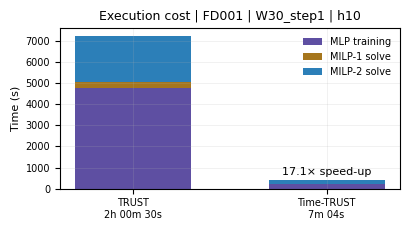

0.0


In [ ]:
out = plot_execution_cost_trust_vs_timetrust(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10",
    root="results",
)

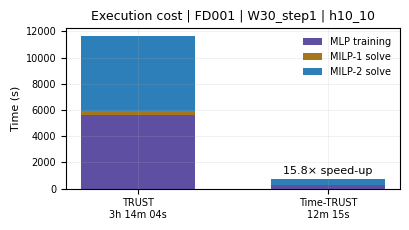

0.0


In [ ]:
out = plot_execution_cost_trust_vs_timetrust(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    root="results",
)

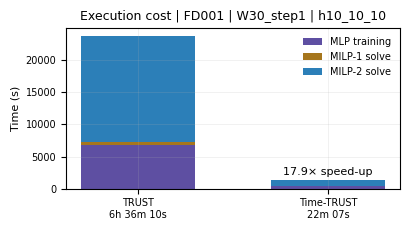

In [2]:
out = plot_execution_cost_trust_vs_timetrust(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10_10_10",
    root="results",
)

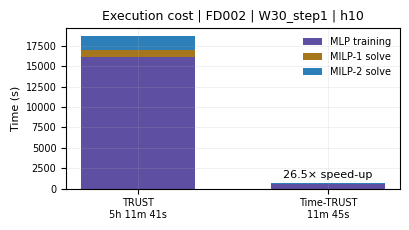

In [3]:
out = plot_execution_cost_trust_vs_timetrust(
    dataset="FD002",
    window_tag="W30_step1",
    hidden_tag="h10",
    root="results",
)